# CIFAR ResNet Infusion - Publication Figures for ICML 2026

This notebook creates publication-ready figures for the ResNet CIFAR experiment section.

**Figures to generate:**
1. Multiple Example Visualization (probe + training images)
2. Bar Chart with Temporal Distribution
3. Key Statistical Tests Summary (Tests 1, 3, 5)

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
import pandas as pd
import seaborn as sns
from glob import glob
from scipy import stats

# Set publication-quality matplotlib parameters
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 8
plt.rcParams['axes.labelsize'] = 9
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['text.usetex'] = False  # Set to True if LaTeX is available

# Create figures directory
os.makedirs('figures', exist_ok=True)

print("Setup complete. Ready to generate figures.")

Setup complete. Ready to generate figures.


In [2]:
# Configuration
RESULTS_DIR = './results/random_test_infusion/'
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
K = 10  # Number of classes

print(f"Results directory: {RESULTS_DIR}")

Results directory: ./results/random_test_infusion/


In [3]:
# Helper functions
def load_experiment_result(exp_dir):
    """Load a single experiment result"""
    result_path = os.path.join(exp_dir, 'results.npz')
    if os.path.exists(result_path):
        return np.load(result_path, allow_pickle=True)
    return None

def softmax(logits):
    """Compute softmax probabilities from logits"""
    exp_logits = np.exp(logits - np.max(logits, axis=-1, keepdims=True))
    return exp_logits / np.sum(exp_logits, axis=-1, keepdims=True)

def denormalize_cifar(img):
    """Denormalize CIFAR-10 image for visualization"""
    # Assuming img is in [0, 1] range
    return np.clip(img, 0, 1)

def show_cifar_image(ax, img, title=None):
    """Display a CIFAR-10 image on an axis"""
    # img should be (C, H, W), convert to (H, W, C)
    img_display = np.transpose(denormalize_cifar(img), (1, 2, 0))
    ax.imshow(img_display)
    ax.axis('off')
    if title:
        ax.set_title(title, fontsize=7)

print("Helper functions loaded.")

Helper functions loaded.


In [4]:
# Load all experiment results
exp_dirs = sorted(glob(os.path.join(RESULTS_DIR, 'sample_*')))
print(f"Found {len(exp_dirs)} experiment directories")

# Load subset for analysis
all_results = []
for exp_dir in exp_dirs:
    result = load_experiment_result(exp_dir)
    if result is not None:
        logits_pre = result['logits_epoch10'][0]
        logits_post = result['logits_infused'][0]
        p_pre = softmax(logits_pre)
        p_post = softmax(logits_post)
        target_class = int(result['target_class'])
        delta_p = p_post[target_class] - p_pre[target_class]
        
        all_results.append({
            'exp_dir': exp_dir,
            'result': result,
            'delta_p': delta_p,
            'target_class': target_class,
            'true_label': int(result['true_label']),
            'p_pre': p_pre,
            'p_post': p_post
        })

print(f"Loaded {len(all_results)} results")

Found 2404 experiment directories
Loaded 2403 results


## Figure 1: Multiple Example Visualization

Show 2-3 examples with probe image + top 5-10 training images (before/after perturbation)

In [5]:
# Select 3 examples: high delta_p, medium, and from different classes
sorted_results = sorted(all_results, key=lambda x: x['delta_p'], reverse=True)

# Select examples
example_indices = [
    0,  # Highest delta_p
    len(sorted_results) // 3,  # Upper-middle
    len(sorted_results) // 2,  # Median
]

selected_examples = [sorted_results[i] for i in example_indices]

# Show selected examples info
for i, ex in enumerate(selected_examples):
    print(f"\nExample {i+1}:")
    print(f"  Δp(target) = {ex['delta_p']:.4f}")
    print(f"  True label: {CLASS_NAMES[ex['true_label']]}")
    print(f"  Target class: {CLASS_NAMES[ex['target_class']]}")
    print(f"  p(target) before: {ex['p_pre'][ex['target_class']]:.4f}")
    print(f"  p(target) after: {ex['p_post'][ex['target_class']]:.4f}")


Example 1:
  Δp(target) = 0.9726
  True label: automobile
  Target class: ship
  p(target) before: 0.0093
  p(target) after: 0.9818

Example 2:
  Δp(target) = 0.2783
  True label: horse
  Target class: airplane
  p(target) before: 0.0003
  p(target) after: 0.2786

Example 3:
  Δp(target) = 0.0915
  True label: airplane
  Target class: airplane
  p(target) before: 0.9033
  p(target) after: 0.9948



Figure 1 saved to figures/figure1_example_visualization.pdf


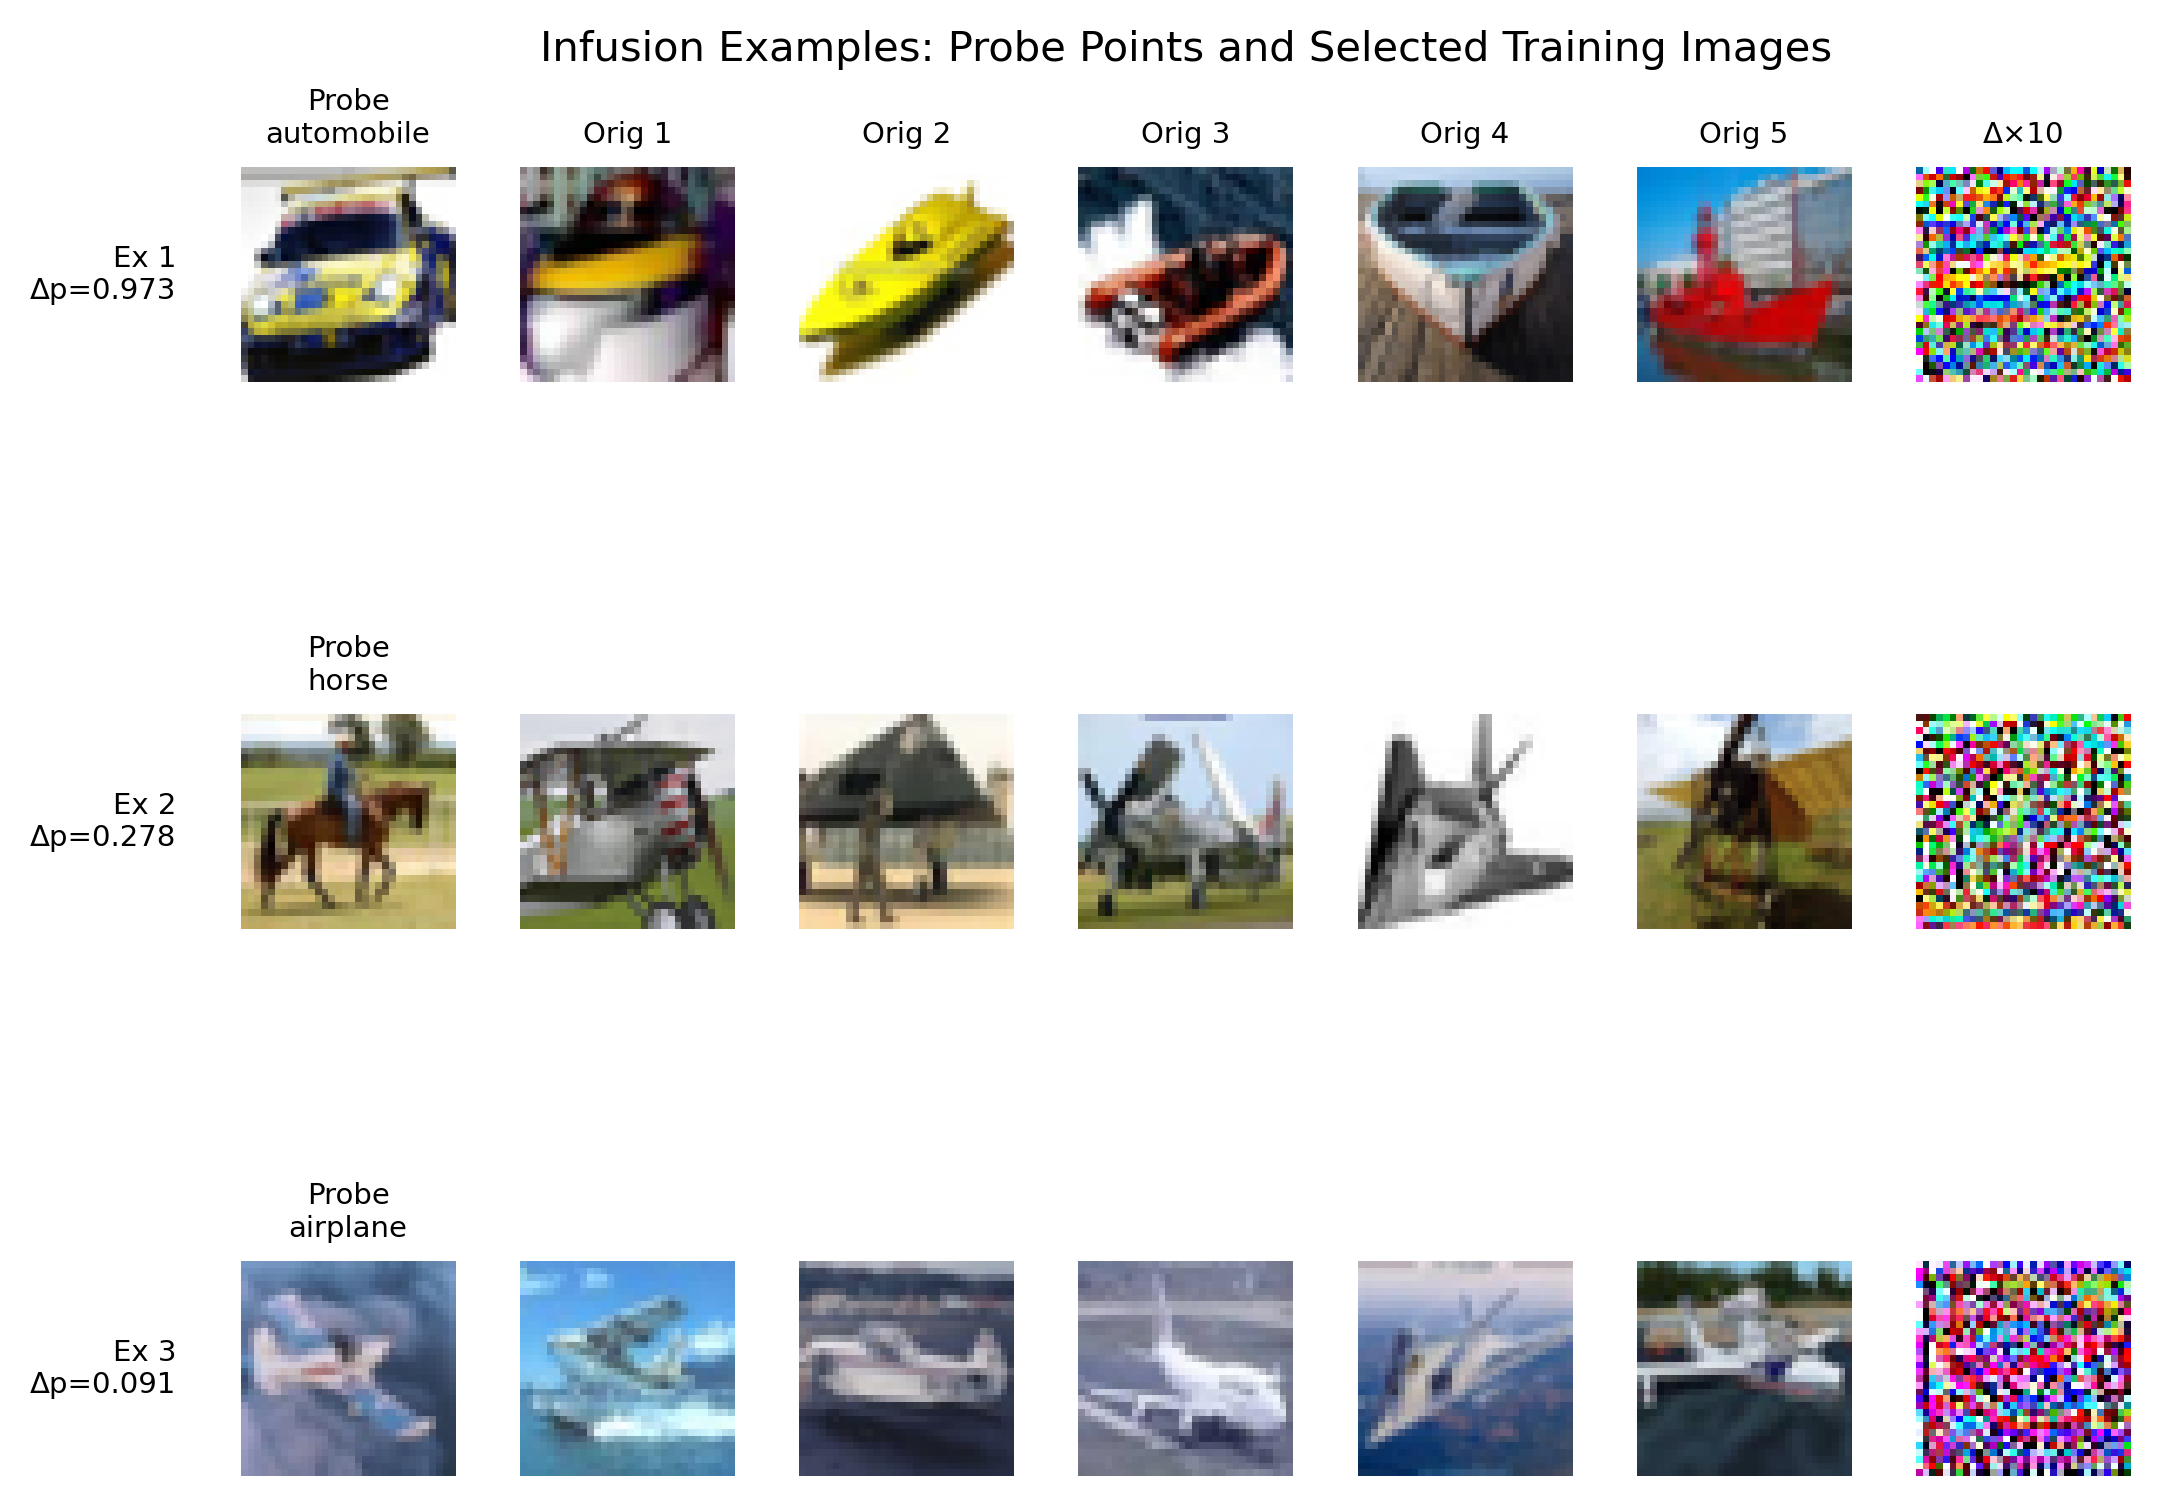

In [6]:
# Create Figure 1: Multiple Examples
N_EXAMPLES = 3
N_TRAIN_SHOW = 5  # Show top 5 training images per example

fig = plt.figure(figsize=(7.0, 5.5))  # ICML two-column width is ~7 inches
gs = gridspec.GridSpec(N_EXAMPLES, N_TRAIN_SHOW + 2, figure=fig, 
                       hspace=0.4, wspace=0.3,
                       left=0.05, right=0.95, top=0.95, bottom=0.05)

for row_idx, example in enumerate(selected_examples):
    result = example['result']
    
    # Probe image
    ax_probe = fig.add_subplot(gs[row_idx, 0])
    probe_img = result['probe_image']
    show_cifar_image(ax_probe, probe_img, f"Probe\n{CLASS_NAMES[example['true_label']]}")
    
    # Add label for this row
    if row_idx == 0:
        ax_probe.text(-0.3, 0.5, f"Ex {row_idx+1}\nΔp={example['delta_p']:.3f}", 
                     transform=ax_probe.transAxes, ha='right', va='center', fontsize=7)
    else:
        ax_probe.text(-0.3, 0.5, f"Ex {row_idx+1}\nΔp={example['delta_p']:.3f}", 
                     transform=ax_probe.transAxes, ha='right', va='center', fontsize=7)
    
    # Top training images (original)
    orig_imgs = result['original_train_images']
    pert_imgs = result['perturbed_train_images']
    
    for i in range(N_TRAIN_SHOW):
        # Original (top half)
        ax_orig = fig.add_subplot(gs[row_idx, i + 1])
        title = f"Orig {i+1}" if row_idx == 0 else None
        show_cifar_image(ax_orig, orig_imgs[i], title)
        
        # Add small border to distinguish original
        for spine in ax_orig.spines.values():
            spine.set_edgecolor('blue')
            spine.set_linewidth(1)
    
    # Difference visualization in last column
    ax_diff = fig.add_subplot(gs[row_idx, -1])
    # Show amplified difference for first training image
    diff = pert_imgs[0] - orig_imgs[0]
    diff_amplified = np.clip(diff * 10 + 0.5, 0, 1)  # Amplify and center at 0.5
    show_cifar_image(ax_diff, diff_amplified, "Δ×10" if row_idx == 0 else None)
    
    # Add border to show it's a difference
    for spine in ax_diff.spines.values():
        spine.set_edgecolor('red')
        spine.set_linewidth(1)

# Add overall title
fig.suptitle('Infusion Examples: Probe Points and Selected Training Images', 
             fontsize=10, y=0.98)

plt.savefig('figures/figure1_example_visualization.pdf', bbox_inches='tight', dpi=300)
plt.savefig('figures/figure1_example_visualization.png', bbox_inches='tight', dpi=300)
print("\nFigure 1 saved to figures/figure1_example_visualization.pdf")
plt.show()

## Figure 3: Bar Chart with Temporal Distribution

Show probability distribution before/after for one example, plus temporal distribution of training examples


Figure 3 saved to figures/figure3_bar_chart_temporal.pdf


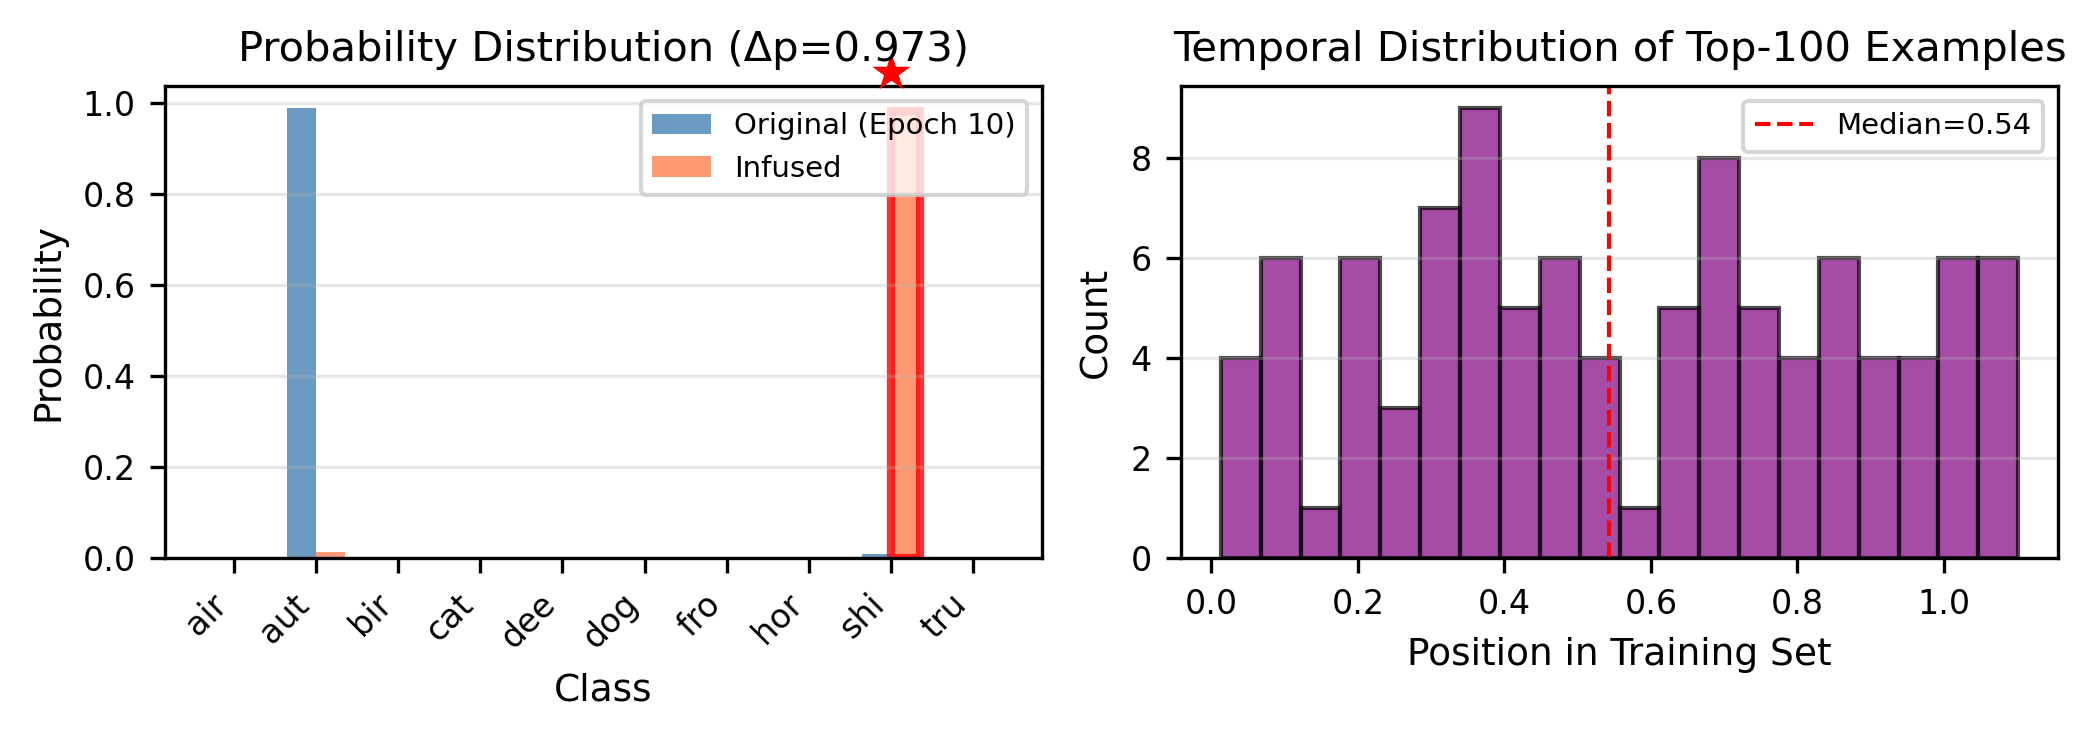

In [7]:
# Use the highest delta_p example
example = selected_examples[0]
result = example['result']

# Create figure with two panels
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.5))

# Left panel: Probability bar chart
ax_bar = axes[0]
x = np.arange(K)
width = 0.35

p_pre = example['p_pre']
p_post = example['p_post']
target_idx = example['target_class']
true_idx = example['true_label']

bars1 = ax_bar.bar(x - width/2, p_pre, width, label='Original (Epoch 10)', 
                   color='steelblue', alpha=0.8)
bars2 = ax_bar.bar(x + width/2, p_post, width, label='Infused', 
                   color='coral', alpha=0.8)

# Highlight target class
bars2[target_idx].set_edgecolor('red')
bars2[target_idx].set_linewidth(2)

ax_bar.set_xlabel('Class')
ax_bar.set_ylabel('Probability')
ax_bar.set_title(f'Probability Distribution (Δp={example["delta_p"]:.3f})')
ax_bar.set_xticks(x)
ax_bar.set_xticklabels([c[:3] for c in CLASS_NAMES], rotation=45, ha='right')
ax_bar.legend(loc='upper right', fontsize=7)
ax_bar.grid(axis='y', alpha=0.3)

# Add annotation for target
ax_bar.text(target_idx, max(p_post[target_idx], p_pre[target_idx]) * 1.05, 
           '★', ha='center', fontsize=12, color='red')

# Right panel: Temporal distribution
ax_temp = axes[1]
train_indices = result['selected_train_indices']
train_size = 45000  # Training set size

# Convert absolute indices to positions (0-1 scale)
positions = np.array(train_indices) / train_size

# Histogram of positions
ax_temp.hist(positions, bins=20, edgecolor='black', alpha=0.7, color='purple')
ax_temp.set_xlabel('Position in Training Set')
ax_temp.set_ylabel('Count')
ax_temp.set_title(f'Temporal Distribution of Top-{len(train_indices)} Examples')
ax_temp.grid(axis='y', alpha=0.3)

# Add vertical line at median
median_pos = np.median(positions)
ax_temp.axvline(median_pos, color='red', linestyle='--', linewidth=1, 
               label=f'Median={median_pos:.2f}')
ax_temp.legend(loc='upper right', fontsize=7)

plt.tight_layout()
plt.savefig('figures/figure3_bar_chart_temporal.pdf', bbox_inches='tight', dpi=300)
plt.savefig('figures/figure3_bar_chart_temporal.png', bbox_inches='tight', dpi=300)
print("\nFigure 3 saved to figures/figure3_bar_chart_temporal.pdf")
plt.show()

## Figure 4: Key Statistical Tests Summary

Show Tests 1, 3, and 5 in a compact 3-panel layout

In [8]:
# Recompute statistics from all results
delta_target = np.array([r['delta_p'] for r in all_results])

# Test 3: Log-odds change
log_odds_change = []
for r in all_results:
    p_pre = r['p_pre']
    p_post = r['p_post']
    t_i = r['target_class']
    
    non_target_mask = np.ones(K, dtype=bool)
    non_target_mask[t_i] = False
    
    p_bar_pre = p_pre[non_target_mask].mean()
    p_bar_post = p_post[non_target_mask].mean()
    
    L_pre = np.log(p_pre[t_i] / (p_bar_pre + 1e-10))
    L_post = np.log(p_post[t_i] / (p_bar_post + 1e-10))
    
    S_i = L_post - L_pre
    log_odds_change.append(S_i)

log_odds_change = np.array(log_odds_change)

# Test 5: Success rates
predicted_pre = np.array([np.argmax(r['p_pre']) for r in all_results])
predicted_post = np.array([np.argmax(r['p_post']) for r in all_results])
targets = np.array([r['target_class'] for r in all_results])

success_pre = (predicted_pre == targets)
success_post = (predicted_post == targets)

R_pre = success_pre.mean()
R_post = success_post.mean()

print(f"Test 1 - Mean Δp: {delta_target.mean():.4f}")
print(f"Test 3 - Mean log-odds: {log_odds_change.mean():.4f}")
print(f"Test 5 - Success rates: {R_pre:.4f} → {R_post:.4f}")

Test 1 - Mean Δp: 0.2341
Test 3 - Mean log-odds: 5.1728
Test 5 - Success rates: 0.0999 → 0.3729



Figure 4 saved to figures/figure4_statistical_tests.pdf


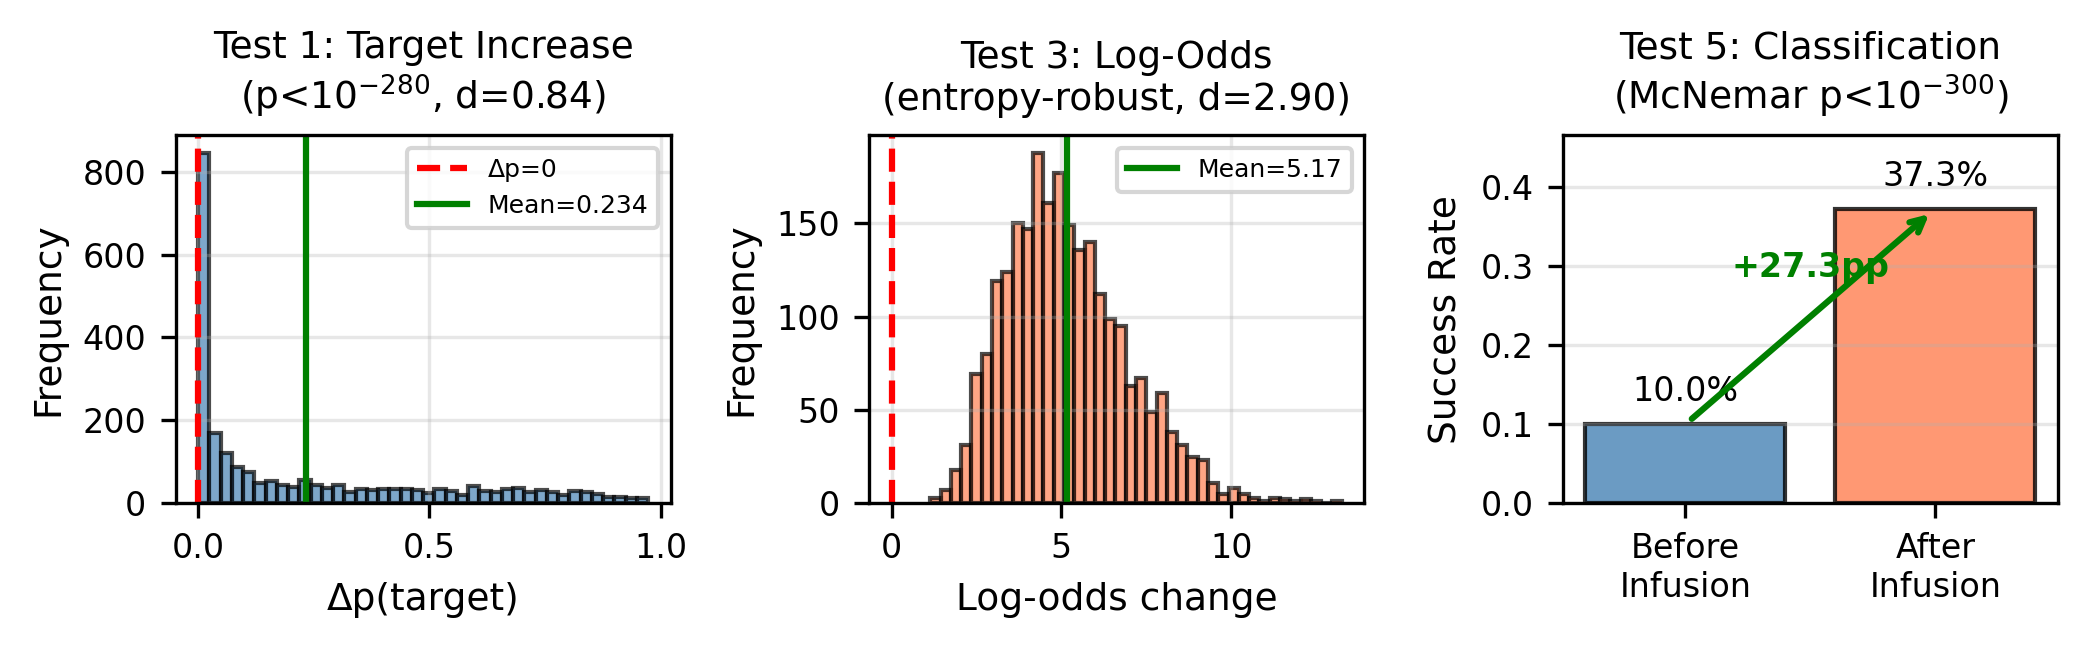

In [9]:
# Create 3-panel figure
fig, axes = plt.subplots(1, 3, figsize=(7.0, 2.2))

# Panel 1: Test 1 - Target Probability Increase
ax1 = axes[0]
ax1.hist(delta_target, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Δp=0')
ax1.axvline(delta_target.mean(), color='green', linestyle='-', linewidth=1.5, 
           label=f'Mean={delta_target.mean():.3f}')
t_stat1, p_val1 = stats.ttest_1samp(delta_target, 0, alternative='greater')
ax1.set_xlabel('Δp(target)')
ax1.set_ylabel('Frequency')
ax1.set_title(f'Test 1: Target Increase\n(p<10$^{{-280}}$, d={delta_target.mean()/delta_target.std():.2f})', 
             fontsize=9)
ax1.legend(fontsize=6, loc='upper right')
ax1.grid(alpha=0.3)

# Panel 2: Test 3 - Log-Odds Change
ax2 = axes[1]
ax2.hist(log_odds_change, bins=40, edgecolor='black', alpha=0.7, color='coral')
ax2.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax2.axvline(log_odds_change.mean(), color='green', linestyle='-', linewidth=1.5,
           label=f'Mean={log_odds_change.mean():.2f}')
cohens_d3 = log_odds_change.mean() / log_odds_change.std()
ax2.set_xlabel('Log-odds change')
ax2.set_ylabel('Frequency')
ax2.set_title(f'Test 3: Log-Odds\n(entropy-robust, d={cohens_d3:.2f})', fontsize=9)
ax2.legend(fontsize=6, loc='upper right')
ax2.grid(alpha=0.3)

# Panel 3: Test 5 - Success Rate
ax3 = axes[2]
labels = ['Before\nInfusion', 'After\nInfusion']
rates = [R_pre, R_post]
colors = ['steelblue', 'coral']
bars = ax3.bar(labels, rates, color=colors, edgecolor='black', alpha=0.8)

# Add value labels on bars
for bar, rate in zip(bars, rates):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{rate:.1%}', ha='center', va='bottom', fontsize=8)

# Add change annotation
ax3.annotate('', xy=(1, R_post), xytext=(0, R_pre),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='green'))
ax3.text(0.5, (R_pre + R_post)/2 + 0.05, f'+{(R_post-R_pre)*100:.1f}pp',
        ha='center', fontsize=8, color='green', weight='bold')

ax3.set_ylabel('Success Rate')
ax3.set_title('Test 5: Classification\n(McNemar p<10$^{-300}$)', fontsize=9)
ax3.set_ylim([0, max(rates) * 1.25])
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/figure4_statistical_tests.pdf', bbox_inches='tight', dpi=300)
plt.savefig('figures/figure4_statistical_tests.png', bbox_inches='tight', dpi=300)
print("\nFigure 4 saved to figures/figure4_statistical_tests.pdf")
plt.show()

## Summary

All publication figures have been generated:
- **Figure 1**: Multiple example visualization (probe + training images)
- **Figure 3**: Bar chart with temporal distribution
- **Figure 4**: Key statistical tests summary

Figures are saved in both PDF (vector) and PNG (raster) formats in the `figures/` directory.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2500005..0.2500069].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2500005..0.25001168].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2500005..0.25001168].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2500005..0.25000602].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2500005..0.2500005].


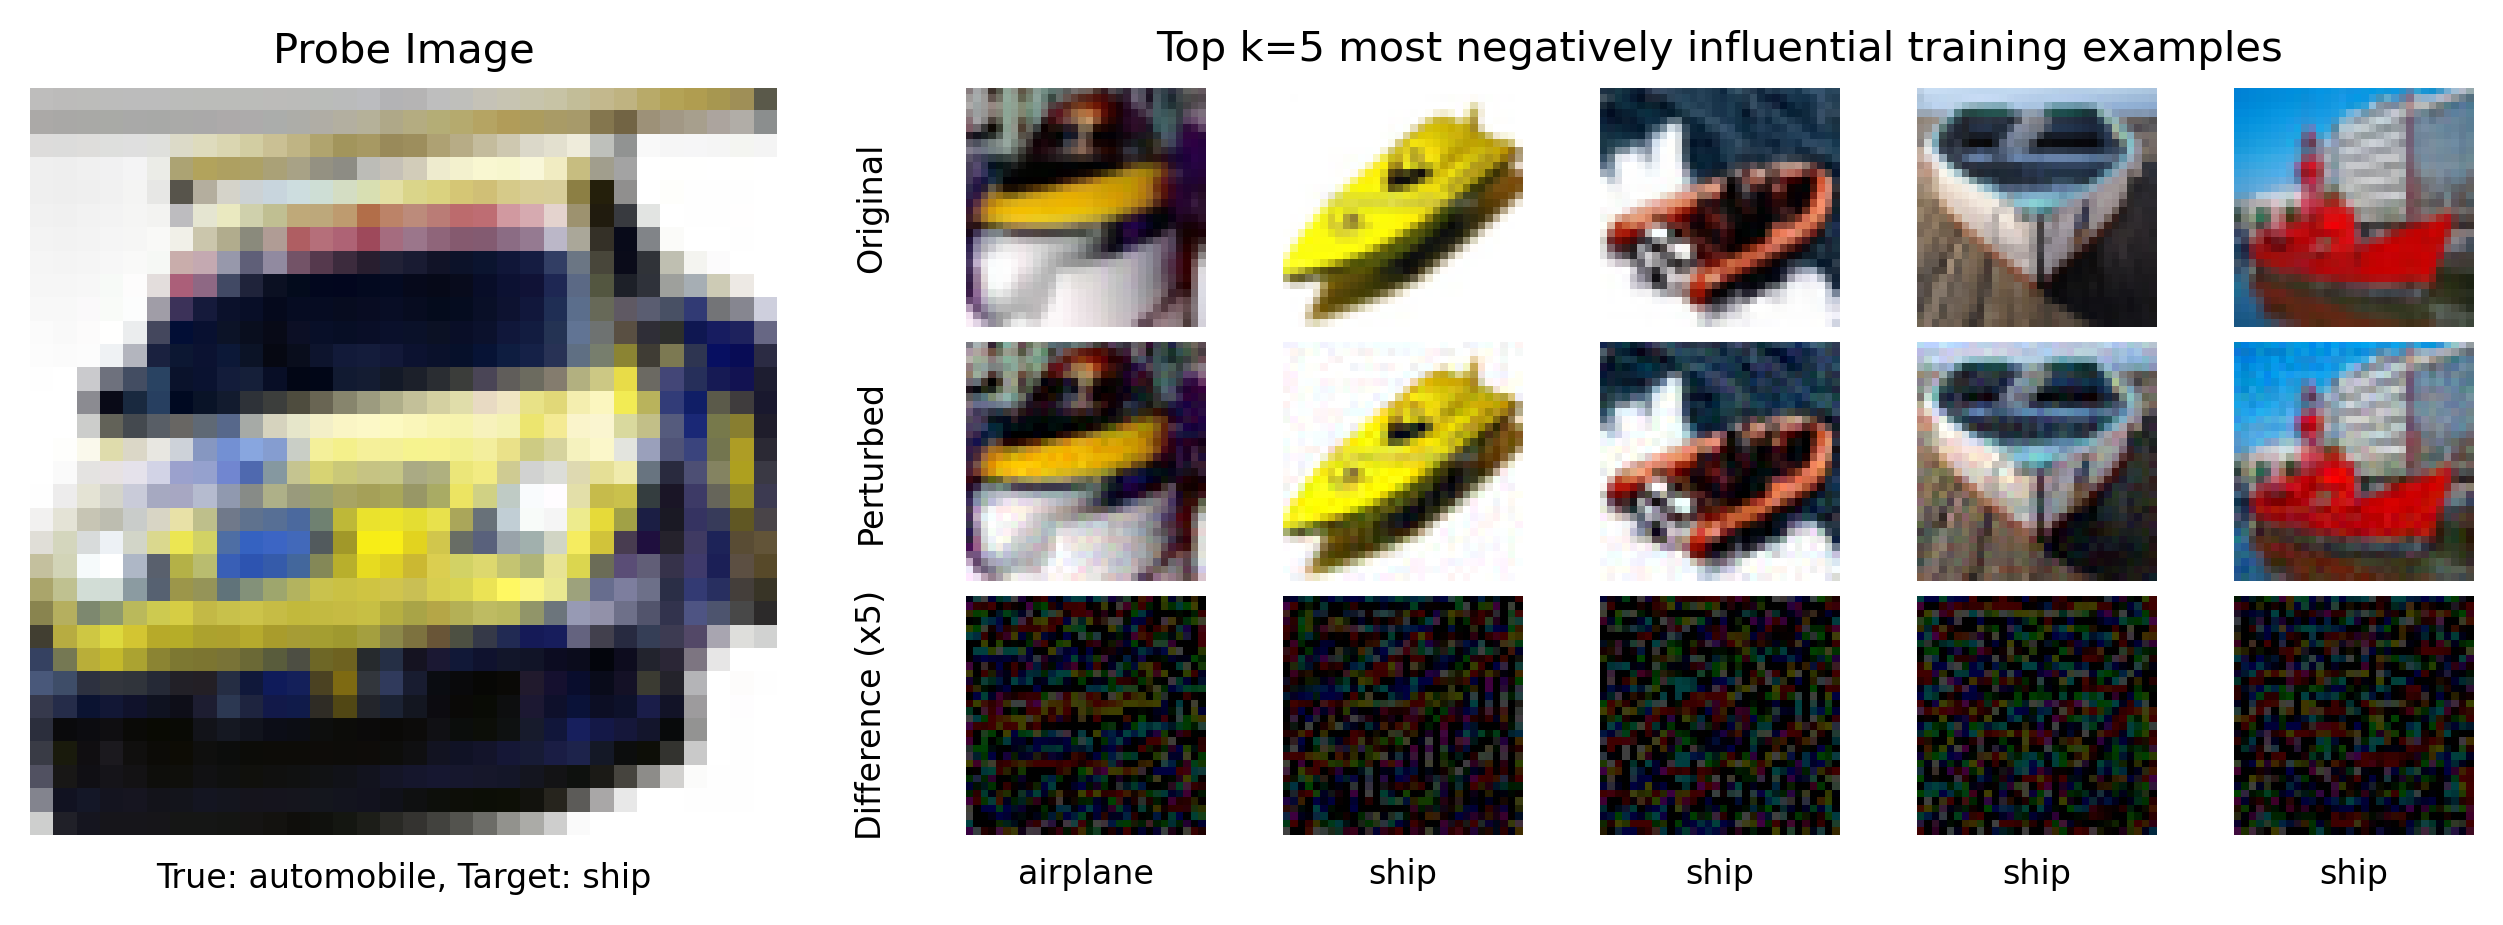

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2500005..0.25000602].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2500005..0.2500093].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2500005..0.25001168].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2500005..0.25001168].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2500005..0.25001168].


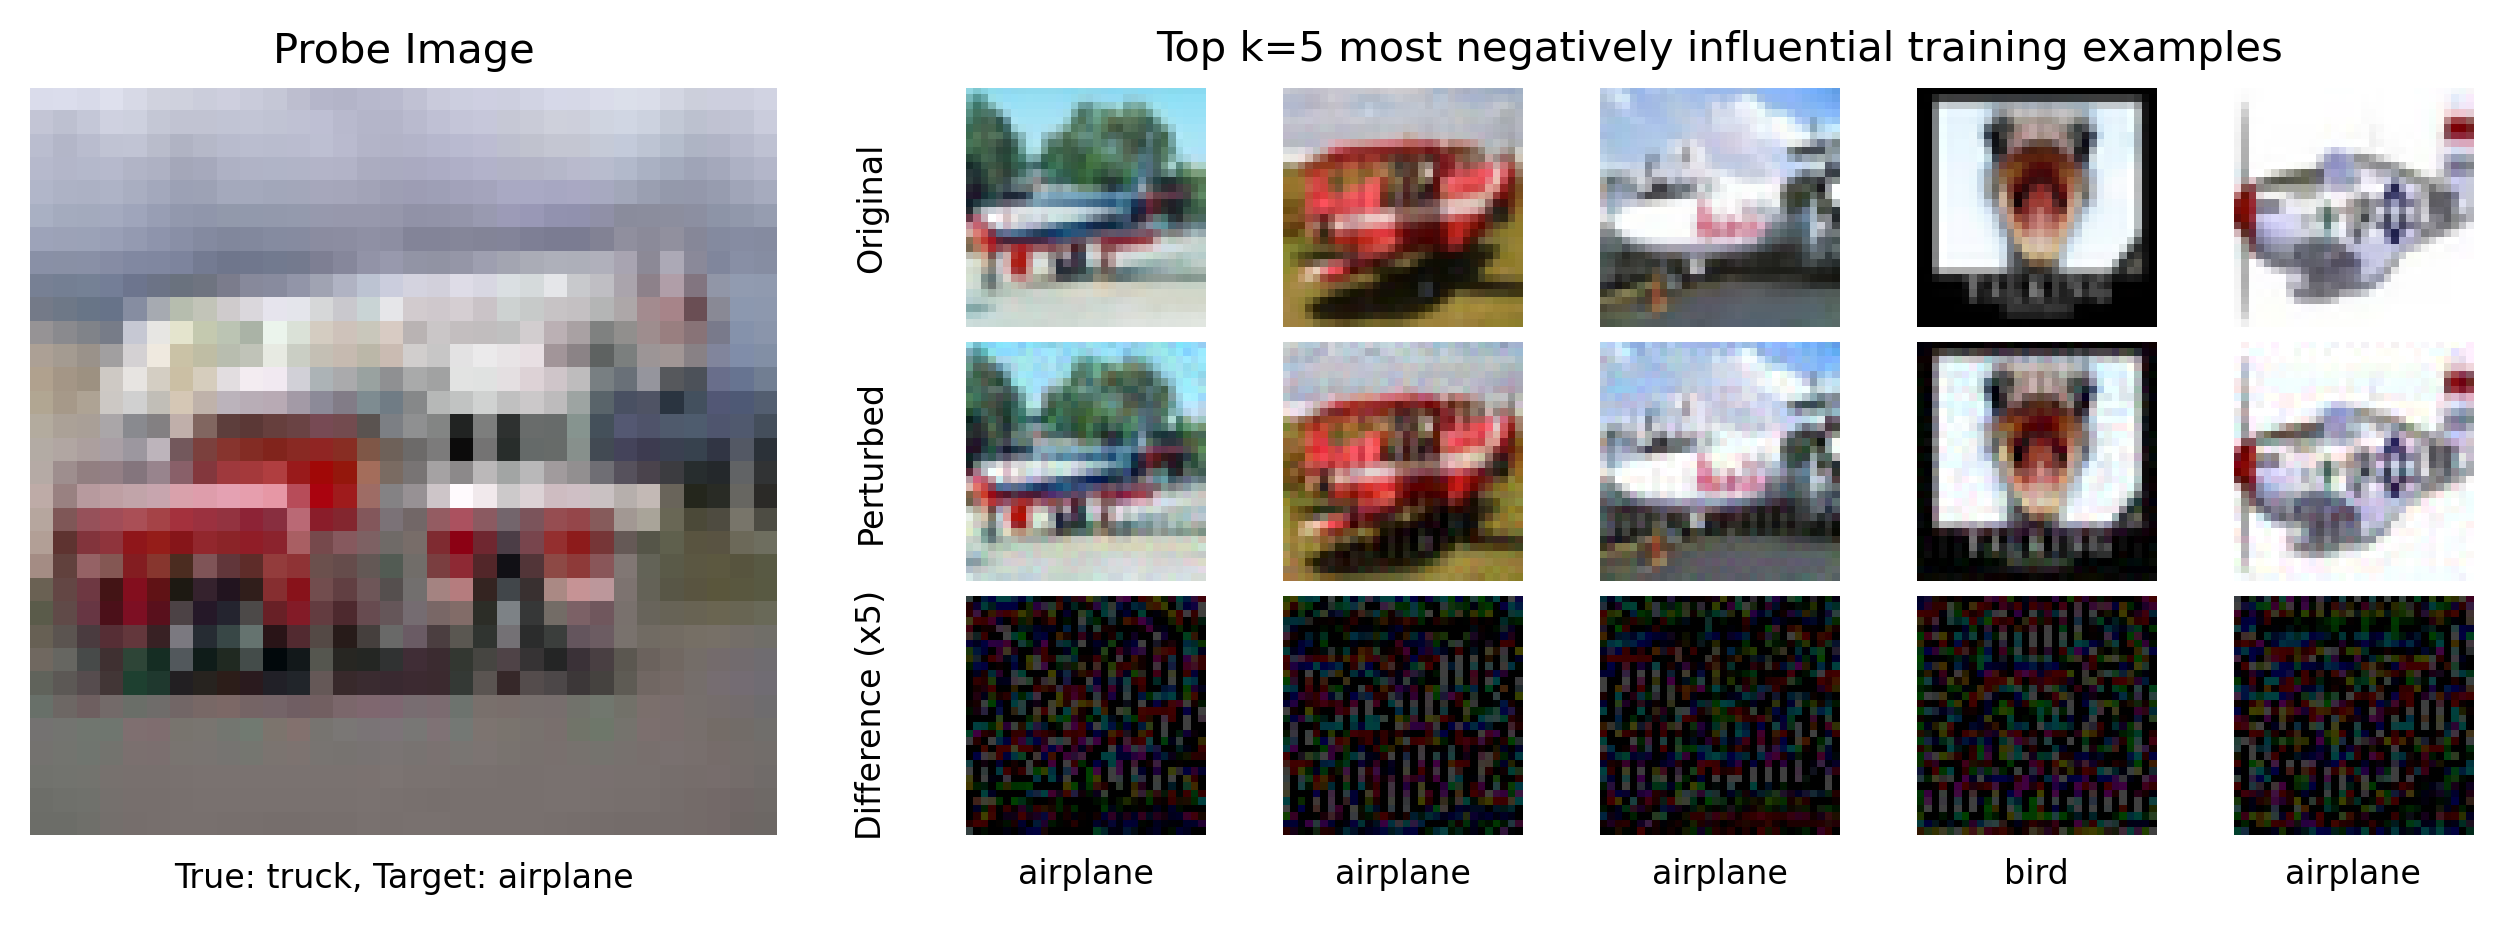

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2500005..0.25001168].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2500005..0.25001168].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2500005..0.25001168].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2500005..0.2500005].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2500005..0.25001168].


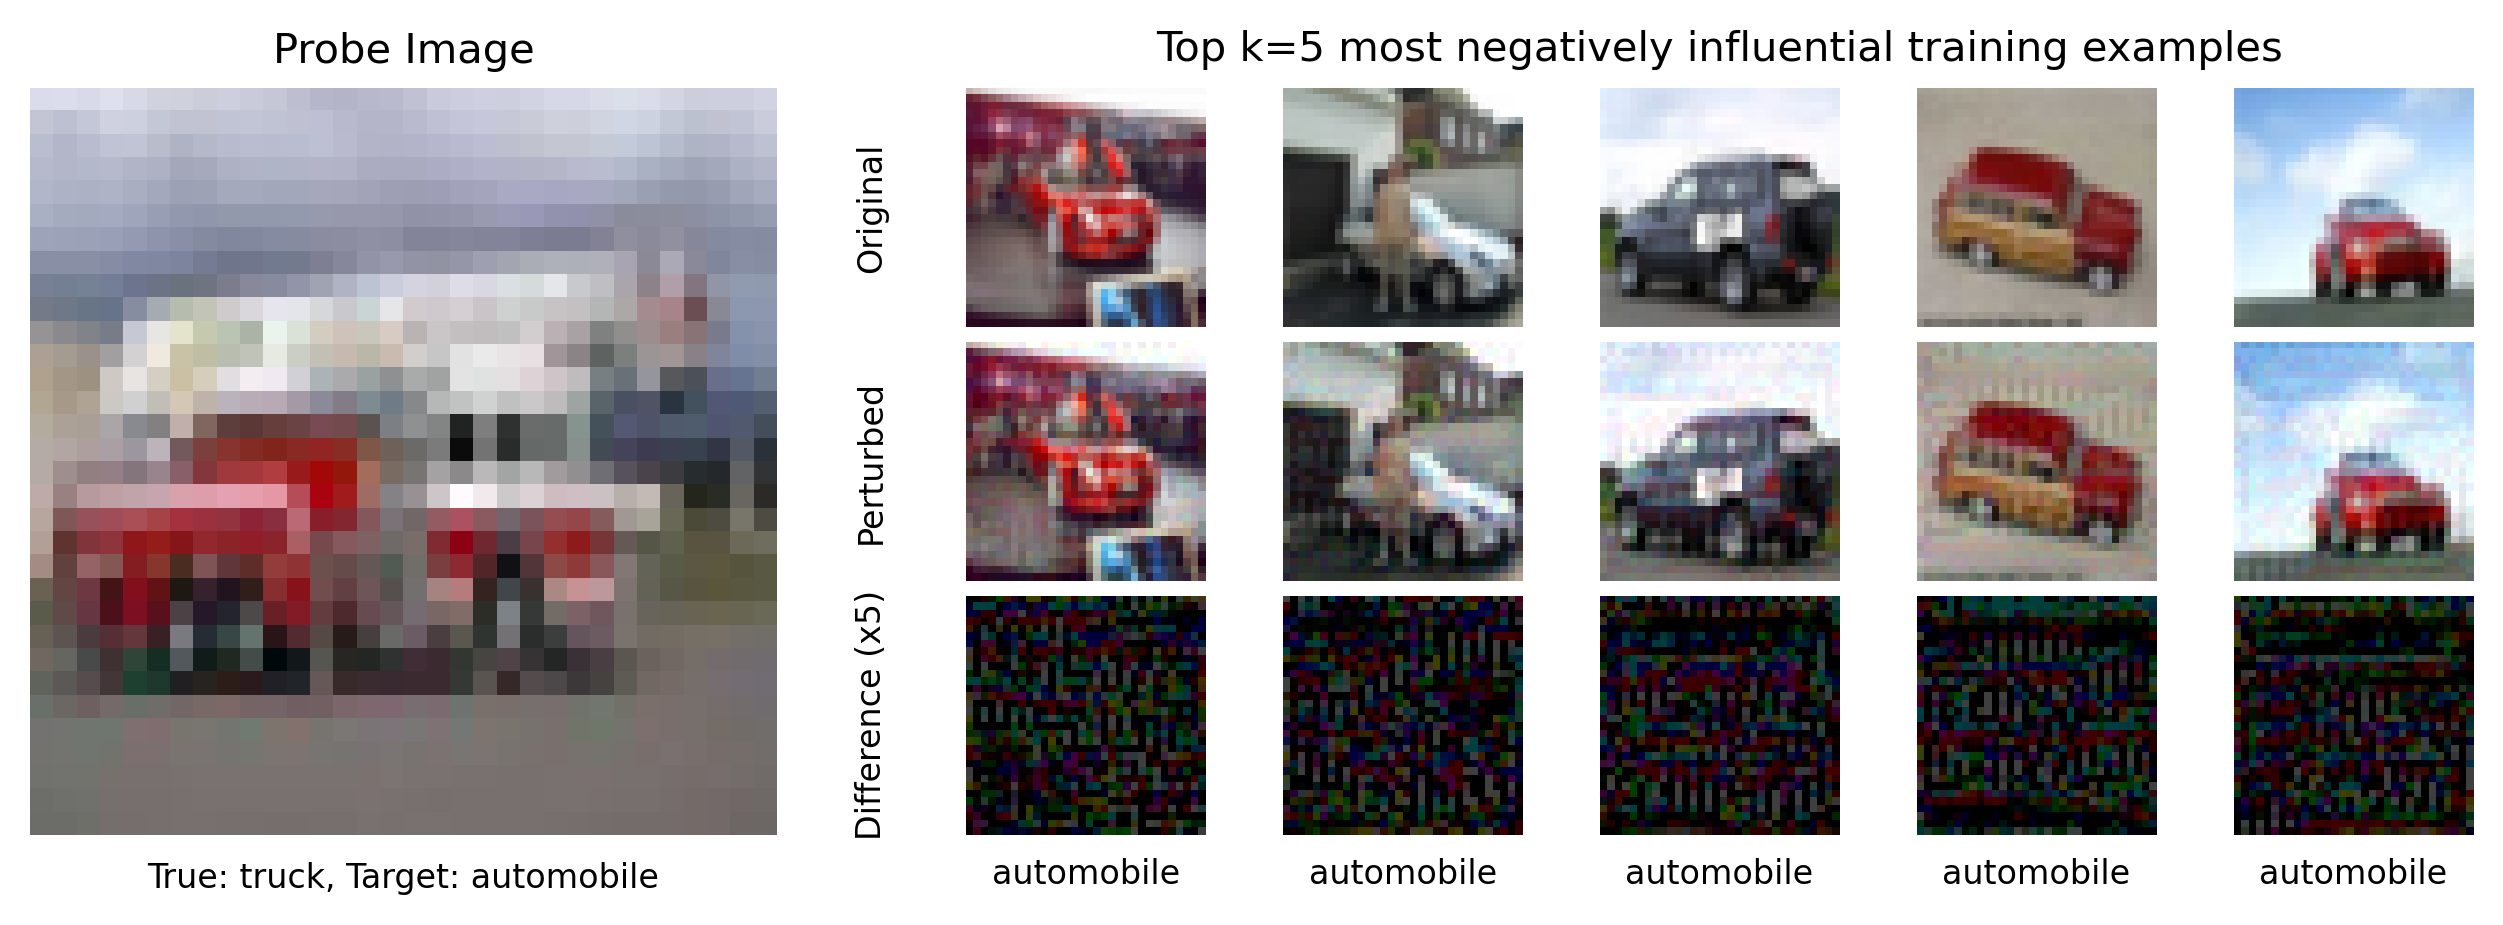

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2500005..0.25000125].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2500005..0.25001168].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2500005..0.2500005].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2500005..0.25000453].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2500005..0.2500005].


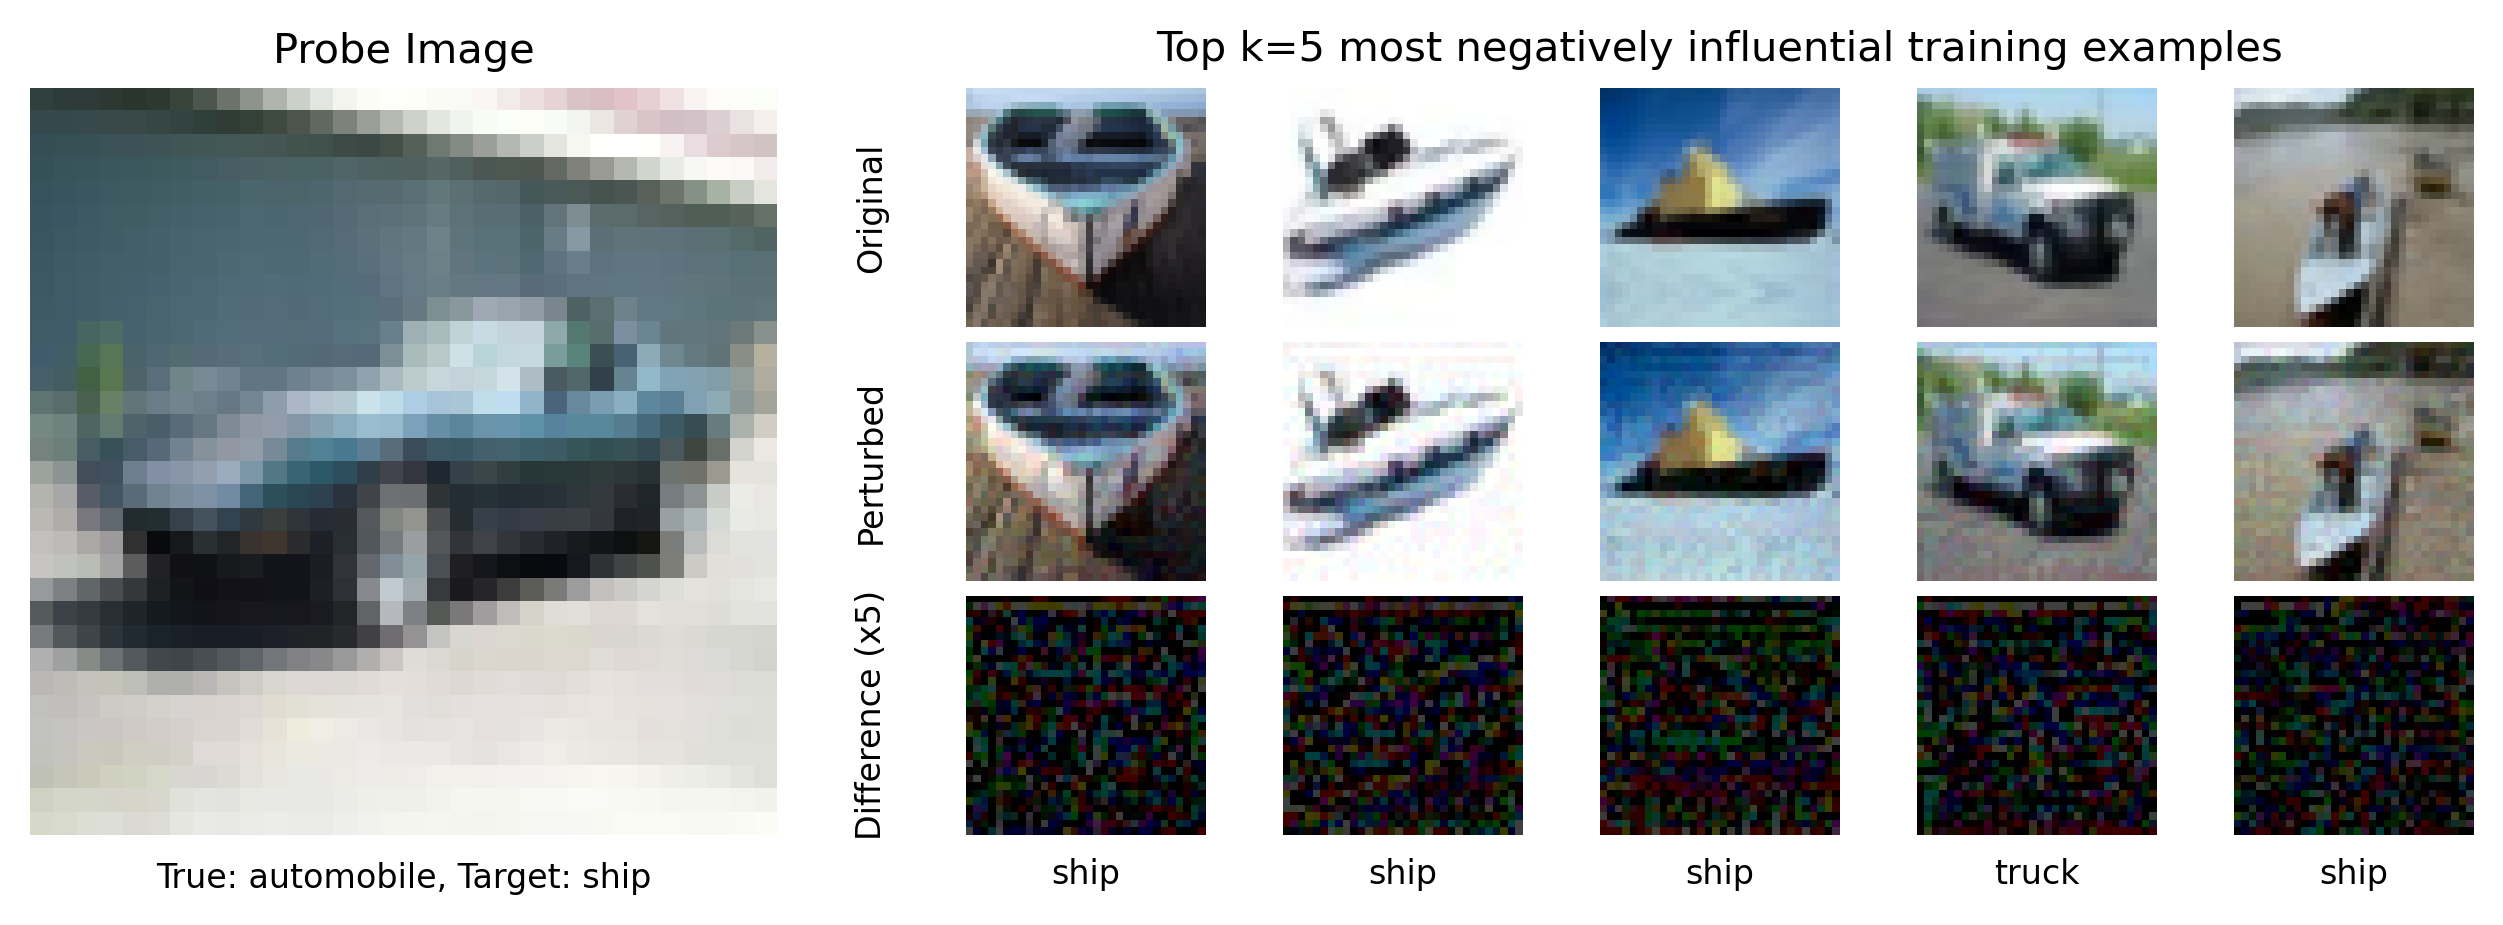

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2500005..0.2500005].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2500005..0.25000453].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2500005..0.25001168].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2500005..0.2500005].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2500005..0.2500005].


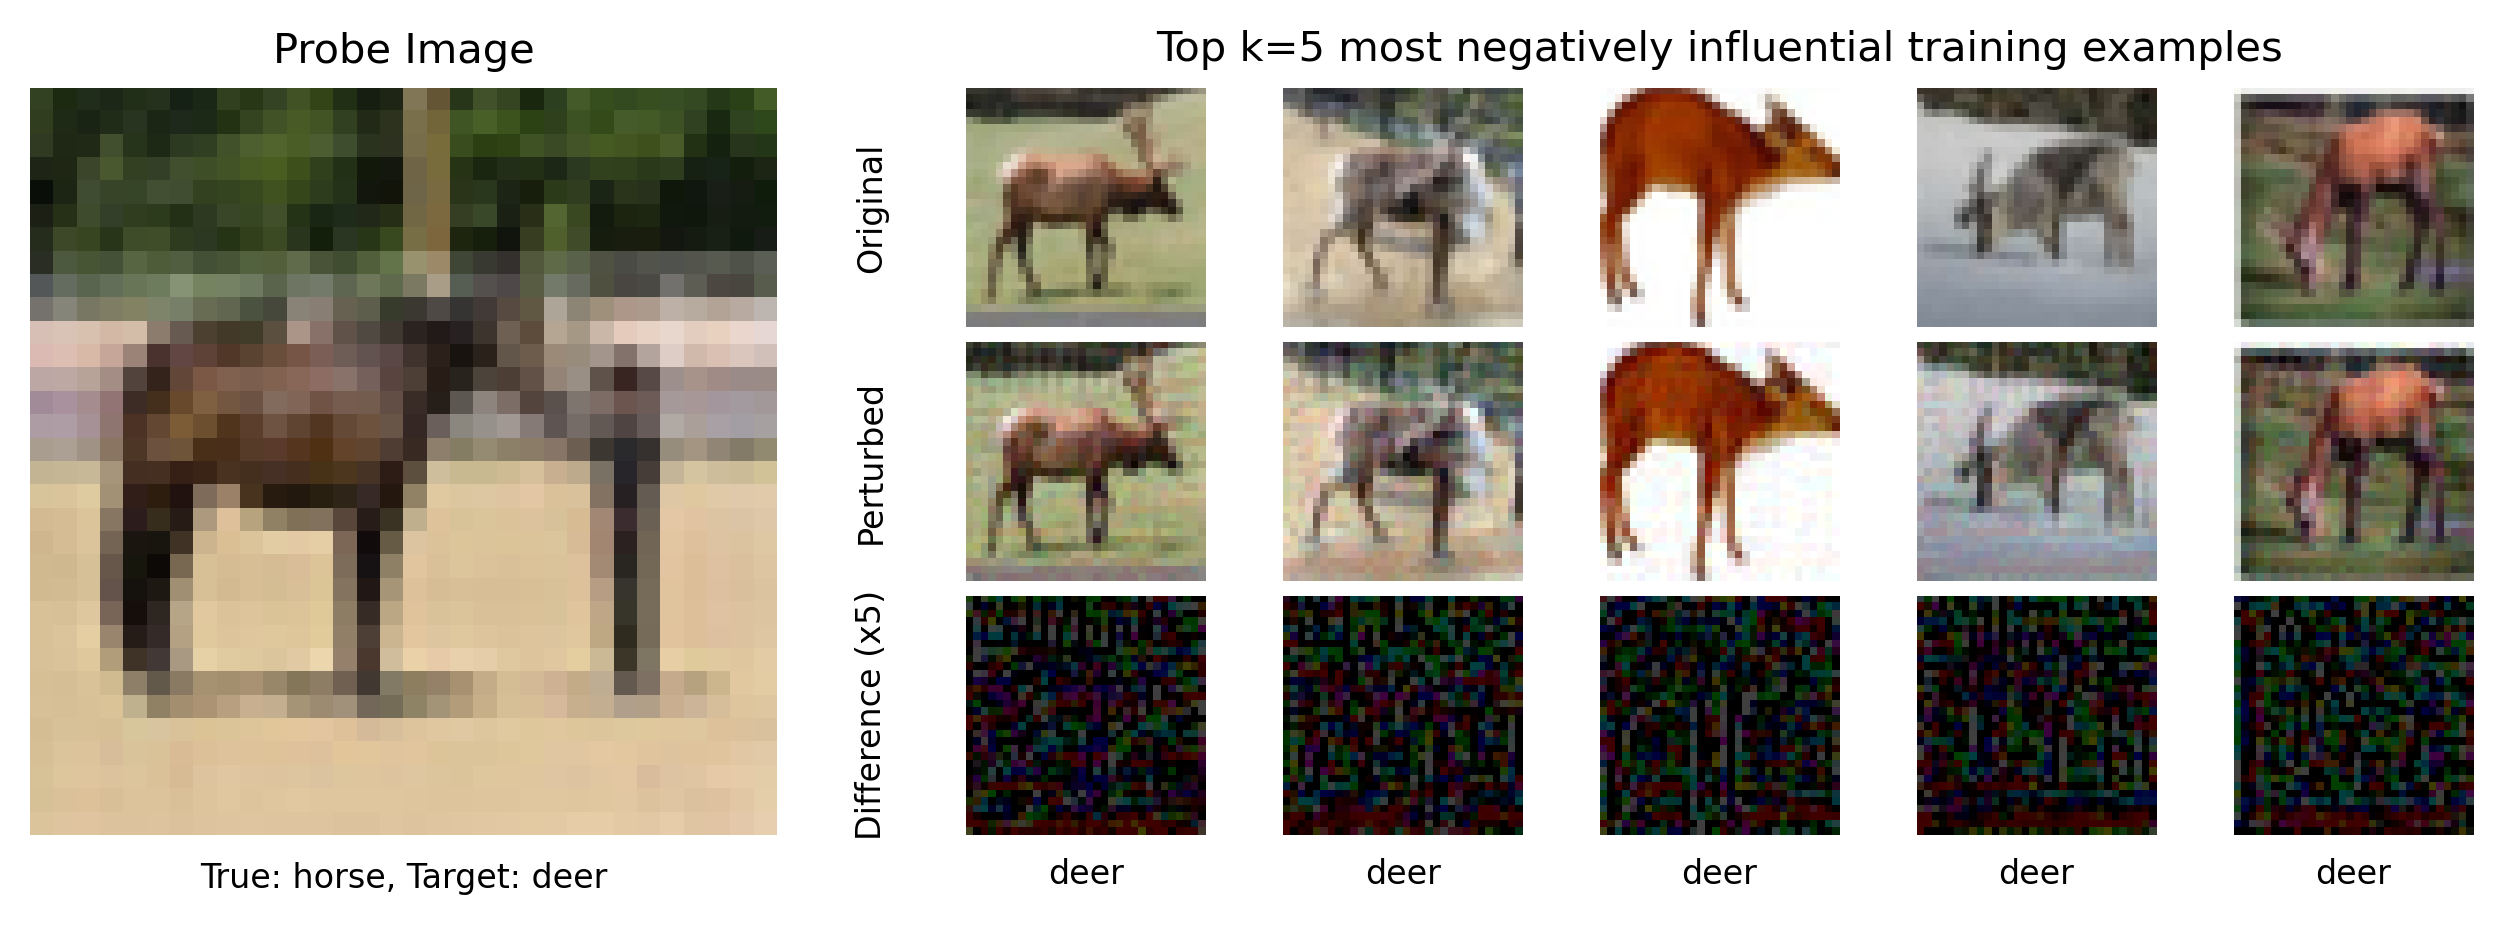

In [43]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

def create_influence_figure(example, n_show=5):
    """Figure with left column = probe image, right column = 3 x n_show grid."""

    result = example['result']
    probe_image = result['probe_image']
    true_label = int(result['true_label'])
    target_class = int(result['target_class'])
    original_train_images = result['original_train_images']
    perturbed_train_images = result['perturbed_train_images']

    if 'original_train_labels' in result:
        original_train_labels = result['original_train_labels']
    else:
        original_train_labels = [0] * len(original_train_images)

    n_show = min(n_show, len(original_train_images))

    # --- Figure + margins ---
    fig = plt.figure(figsize=(8, 3))
    left, right, top, bottom = 0.04, 0.98, 0.95, 0.12

    # 2 main columns: [probe] | [3 x n_show grid]
    gs_main = gridspec.GridSpec(
        1, 2,
        figure=fig,
        width_ratios=[1, n_show],
        left=left, right=right, top=top, bottom=bottom,
        wspace=0.4
    )

    # ---- Left: probe axes (we'll resize it later) ----
    ax_probe = fig.add_subplot(gs_main[0, 0])
    show_cifar_image(ax_probe, probe_image)   # aspect='equal' by default
    ax_probe.set_xticks([])
    ax_probe.set_yticks([])
    ax_probe.set_title("Probe Image", fontsize=10)

    for spine in ax_probe.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('black')
        spine.set_linewidth(2)

    # ---- Right: 3 x n_show grid ----
    gs_right = gridspec.GridSpecFromSubplotSpec(
        3, n_show,
        subplot_spec=gs_main[0, 1],
        hspace=0.06,
        wspace=0.06
    )

    ax_row0 = ax_row1 = ax_row2 = None
    ax_grid = []
    col_labels = []

    for i in range(n_show):
        label_i = original_train_labels[i]
        train_class = CLASS_NAMES[int(label_i)] if isinstance(label_i, (int, np.integer)) else str(label_i)
        col_labels.append(train_class)

        # Row 0: original
        ax_orig = fig.add_subplot(gs_right[0, i])
        show_cifar_image(ax_orig, original_train_images[i], None)

        # Row 1: perturbed
        ax_pert = fig.add_subplot(gs_right[1, i])
        show_cifar_image(ax_pert, perturbed_train_images[i])

        # Row 2: difference
        ax_diff = fig.add_subplot(gs_right[2, i])
        diff = perturbed_train_images[i] - original_train_images[i]
        diff_display = np.transpose(diff, (1, 2, 0))
        diff_display = np.clip(diff_display * 5, -1, 1)
        ax_diff.imshow(diff_display, cmap='bwr', vmin=-1, vmax=1)
        ax_diff.axis('off')

        if i == 0:
            ax_row0, ax_row1, ax_row2 = ax_orig, ax_pert, ax_diff

        ax_grid.append((ax_orig, ax_pert, ax_diff))

    # ---- Title above the 3 x n_show grid ----------------------------------
    if ax_grid:
        bbox0 = ax_grid[0][0].get_position()     # first column, top row
        bboxN = ax_grid[-1][0].get_position()    # last column, top row

        x0 = bbox0.x0
        xN = bboxN.x1
        x_center = 0.5 * (x0 + xN)
        y_top = bbox0.y1 + 0.03                 # small offset above top row

        fig.text(
            x_center,
            y_top,
            f"Top k={n_show} most negatively influential training examples",
            ha='center', fontsize=10
        )

    # ---- Now resize & align the probe axes ---------------------------------
    # We want its top and bottom to match top of row0 and bottom of row2.
    if ax_row0 is not None and ax_row2 is not None:
        bbox_top = ax_row0.get_position()
        bbox_bot = ax_row2.get_position()

        y0 = bbox_bot.y0
        y1 = bbox_top.y1
        height = y1 - y0

        # Get image aspect ratio (width / height)
        if probe_image.ndim == 3:
            if probe_image.shape[0] in (1, 3):  # (C, H, W)
                img_h, img_w = probe_image.shape[1], probe_image.shape[2]
            else:                               # (H, W, C)
                img_h, img_w = probe_image.shape[0], probe_image.shape[1]
        else:                                   # (H, W)
            img_h, img_w = probe_image.shape
        img_ratio = img_w / img_h

        # Center the probe within its original horizontal slot
        bbox_probe = ax_probe.get_position()
        x_center = 0.5 * (bbox_probe.x0 + bbox_probe.x1)
        width = height * img_ratio
        x0 = x_center - width / 2.0

        ax_probe.set_position([x0, y0, width, height])
        ax_probe.set_aspect('equal')  # keep the image square

    # ---- Text that depends on final positions ------------------------------

    # Probe label underneath
    bbox = ax_probe.get_position()
    fig.text(
        (bbox.x0 + bbox.x1) / 2,
        bbox.y0 - 0.03,
        f"True: {CLASS_NAMES[true_label]}, Target: {CLASS_NAMES[target_class]}",
        ha='center', va='top', fontsize=8
    )

    # Row labels between probe and grid
    if ax_row0 is not None:
        bbox_probe = ax_probe.get_position()
        bbox0 = ax_row0.get_position()
        bbox1 = ax_row1.get_position()
        bbox2 = ax_row2.get_position()

        x_label = (bbox_probe.x1 + bbox0.x0) / 2.0

        y0 = (bbox0.y0 + bbox0.y1) / 2.0
        y1 = (bbox1.y0 + bbox1.y1) / 2.0
        y2 = (bbox2.y0 + bbox2.y1) / 2.0

        fig.text(x_label, y0, 'Original',
                 fontsize=8, va='center', ha='center', rotation=90)
        fig.text(x_label, y1, 'Perturbed',
                 fontsize=8, va='center', ha='center', rotation=90)
        fig.text(x_label, y2, 'Difference (x5)',
                 fontsize=8, va='center', ha='center', rotation=90)

    # Column labels under each right-hand column
    for i in range(n_show):
        ax_diff = ax_grid[i][2]
        bbox = ax_diff.get_position()
        x = (bbox.x0 + bbox.x1) / 2
        y = bbox.y0 - 0.025
        fig.text(x, y, col_labels[i],
                 ha='center', va='top', fontsize=8)

    return fig


sorted_results = sorted(all_results, key=lambda x: x['delta_p'], reverse=True)
selected_examples_2 = sorted_results
for example_best in selected_examples_2[:5]:
    fig2 = create_influence_figure(example_best, n_show=5)
    plt.show()